# ***Pneumonia Detection from Chest X-Ray Images Using Convolutional Neural Networks (CNN)***

# *Project Overview*

***Pneumonia is a serious respiratory infection that inflames the air sacs in one or both lungs, and timely, accurate diagnosis is critical for effective treatment. Chest X-rays are the most common imaging tool used to diagnose pneumonia, but manual interpretation can be time-consuming and subject to human error. This project focuses on classifying chest X-ray images using a Convolutional Neural Network (CNN). The model learns important visual features from X-ray images and classifies them into two categories: Normal and Pneumonia. The aim of this project is to develop an accurate and efficient CNN-based model that supports radiologists and clinicians in the early detection of pneumonia, evaluated using metrics such as Accuracy, Precision, Recall, F1-Score, Confusion Matrix, and the ROC-AUC score.***


# *Project Objectives*

* ***To classify chest X-ray images using a Convolutional Neural Network (CNN).***
* ***To preprocess chest X-ray images through resizing, normalization, and image augmentation techniques for improved model performance.***
* ***To classify chest X-ray images into two categories: Normal and Pneumonia.***
* ***To evaluate the model using performance metrics such as Accuracy, Precision, Recall, F1-Score, Confusion Matrix, and ROC-AUC score.***
* ***To develop an efficient deep learning model that supports early detection of pneumonia and assists healthcare professionals in timely diagnosis.***

##*Dataset Description*

*The dataset used in this project is the publicly available* **Chest X-Ray Images (Pneumonia)** *dataset (originally released by Kermany et al., hosted on Kaggle). It contains chest X-ray images organized into three pre-split folders —* **train, val,** *and* **test** *— each containing two class sub-folders,* **NORMAL** and **PNEUMONIA**. *There are roughly* **5,863** *images in total, with the training set noticeably imbalanced (more Pneumonia images than Normal images). The images were preprocessed by resizing and normalizing before training the CNN model. Data augmentation techniques, such as rotation, zooming, shear, and horizontal flipping, were applied to increase the diversity of the training data, improve the model's generalization ability, and reduce overfitting.*


In [ ]:
#import libraries
import random
random.seed(10)
import numpy as np
np.random.seed(10)
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.image as mpimg
from PIL import Image
import tensorflow as tf
from tensorflow import keras
print(tf.__version__)

2.20.0


# *Checking each folder*

*This step verifies that the dataset contains the required split folders* (**train, val, test**) *and the two disease class folders within each* (**NORMAL, PNEUMONIA**)*. Ensuring the dataset is properly organized before preprocessing, augmentation, and model training helps avoid errors later in the pipeline.*


In [ ]:
# Step 1: Set up kaggle package is installed
!pip install -q kaggle

# --- Step 2: Download and Extract the Dataset ---
# The dataset slug for 'Chest X-Ray Images (Pneumonia)' is 'paultimothymooney/chest-xray-pneumonia'
# Download the dataset to the /content/ directory
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia -p /content/

# Unzip the main dataset archive. This will create a 'chest_xray' directory in /content/
# and place train, val, test, and another chest_xray.zip inside it.
!yes | unzip -qo /content/chest-xray-pneumonia.zip -d /content/

# Remove the downloaded zip file to save space
!rm /content/chest-xray-pneumonia.zip

# Verify that the directory now exists and contains content
import os
print(f"Contents of /content/chest_xray:")
print(os.listdir('/content/chest_xray'))

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [00:13<00:00, 184MB/s]

Contents of /content/chest_xray:
['val', 'train', 'chest_xray', 'test', '__MACOSX']


In [ ]:
# Base path to the dataset (Kaggle: chest-xray-pneumonia dataset)
BASE_DIR = "/content/chest_xray"

print(os.listdir(BASE_DIR))

['val', 'train', 'chest_xray', 'test', '__MACOSX']


In [ ]:
train_dir = os.path.join(BASE_DIR, "train")
val_dir = os.path.join(BASE_DIR, "val")
test_dir = os.path.join(BASE_DIR, "test")

print("Train classes:", os.listdir(train_dir))
print("Val classes:", os.listdir(val_dir))
print("Test classes:", os.listdir(test_dir))

Train classes: ['PNEUMONIA', 'NORMAL']
Val classes: ['PNEUMONIA', 'NORMAL']
Test classes: ['PNEUMONIA', 'NORMAL']


# *Checking the no. of images in each class*

*This step counts the number of chest X-ray images available in each class for every split, to analyze the dataset distribution. The output helps identify the class imbalance between* **NORMAL** *and* **PNEUMONIA** *images, which is important context before training, since imbalance can bias the model toward the majority class.*


In [ ]:
CATEGORIES = ["NORMAL", "PNEUMONIA"]

for split, split_dir in [("train", train_dir), ("val", val_dir), ("test", test_dir)]:
    for cat in CATEGORIES:
        cat_dir = os.path.join(split_dir, cat)
        print(f"{split:5s} | {cat:10s} : {len(os.listdir(cat_dir))} images")

train | NORMAL     : 1341 images
train | PNEUMONIA  : 3875 images
val   | NORMAL     : 8 images
val   | PNEUMONIA  : 8 images
test  | NORMAL     : 234 images
test  | PNEUMONIA  : 390 images


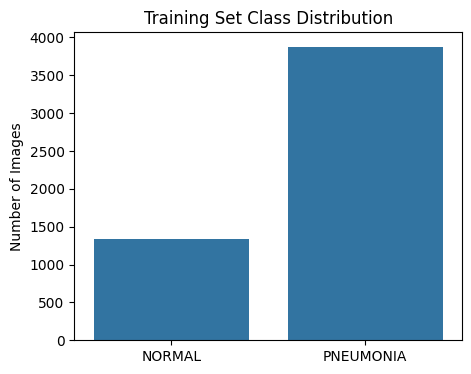

In [ ]:
# Visualize the class distribution in the training set
train_counts = [len(os.listdir(os.path.join(train_dir, cat))) for cat in CATEGORIES]

plt.figure(figsize=(5,4))
sns.barplot(x=CATEGORIES, y=train_counts)
plt.title("Training Set Class Distribution")
plt.ylabel("Number of Images")
plt.show()

# *Visualizing the images in each class and checking the image shape*

*This step uses the Pillow (PIL) library to load and display sample chest X-ray images from each class*—**NORMAL and PNEUMONIA**. *The images are visually inspected, and their dimensions and file formats are verified to ensure they are correctly loaded and ready for image preprocessing, augmentation, and deep learning model training*.


NORMAL | shape: (1302, 1700) | format: JPEG
NORMAL | shape: (1306, 1596) | format: JPEG
NORMAL | shape: (1666, 1990) | format: JPEG


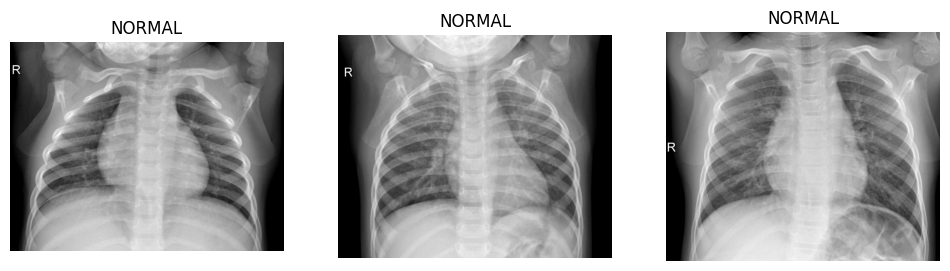

PNEUMONIA | shape: (656, 1024) | format: JPEG
PNEUMONIA | shape: (1032, 1152) | format: JPEG
PNEUMONIA | shape: (752, 1256) | format: JPEG


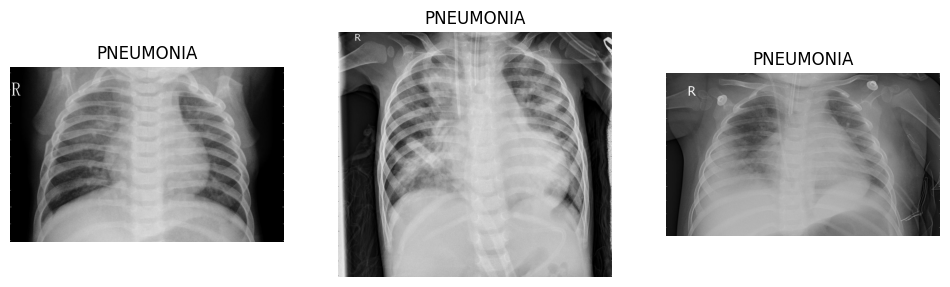

In [ ]:
data_paths = {
    "NORMAL": os.path.join(train_dir, "NORMAL"),
    "PNEUMONIA": os.path.join(train_dir, "PNEUMONIA")
}

# Number of images to display from each class
num_images_to_display = 3

for category_name, path in data_paths.items():
    image_files = [f for f in os.listdir(path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

    plt.figure(figsize=(12,4))
    for i, image_file in enumerate(image_files[:num_images_to_display]):
        image_path = os.path.join(path, image_file)
        img = Image.open(image_path)
        print(category_name, "| shape:", np.array(img).shape, "| format:", img.format)

        plt.subplot(1, num_images_to_display, i+1)
        plt.imshow(img, cmap="gray")
        plt.title(category_name)
        plt.axis('off')
    plt.show()

# *Preprocessing: Resizing and Normalizing Image Data*

*In this step, the chest X-ray images are resized to a fixed input size (150x150) so they can be fed into the CNN, and pixel values are normalized by dividing by 255, scaling them to a range between 0 and 1. Since the raw dataset already comes as an organized folder structure (train/val/test, each with NORMAL and PNEUMONIA sub-folders),* **ImageDataGenerator** *is used to read images directly from disk in batches, apply this normalization, and (for the training set) apply data augmentation — this is more memory-efficient than loading thousands of X-ray images into a single NumPy array.*


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (150, 150)
BATCH_SIZE = 32

# Training data: normalization + augmentation to improve generalization and reduce overfitting
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,          # Random rotations
    width_shift_range=0.1,      # Random horizontal shifts
    height_shift_range=0.1,     # Random vertical shifts
    shear_range=0.1,            # Random shearing
    zoom_range=0.15,            # Random zoom
    horizontal_flip=True,       # Random horizontal flip
    fill_mode='nearest'
)

# Validation and test data: normalization only (no augmentation)
val_test_datagen = ImageDataGenerator(rescale=1./255)

In [ ]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode='grayscale',
    class_mode='binary',
    shuffle=True,
    seed=10
)

val_generator = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode='grayscale',
    class_mode='binary',
    shuffle=False
)

test_generator = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode='grayscale',
    class_mode='binary',
    shuffle=False
)

print(train_generator.class_indices)

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
{'NORMAL': 0, 'PNEUMONIA': 1}


# *Handling Class Imbalance*

*As seen in the class distribution step, the training set contains noticeably more* **PNEUMONIA** *images than* **NORMAL** *images. To prevent the model from becoming biased toward the majority class, class weights are computed and passed into training so that mistakes on the minority (NORMAL) class are penalized more heavily.*


In [ ]:
from sklearn.utils.class_weight import compute_class_weight

labels = train_generator.classes
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=labels
)
class_weights = dict(enumerate(class_weights_array))
print("Class weights:", class_weights)

Class weights: {0: np.float64(1.9448173005219984), 1: np.float64(0.6730322580645162)}


# *Building the CNN Model*

*A CNN is built from scratch with stacked convolution + max-pooling blocks that progressively extract features (edges, textures, opacities) from the chest X-ray images, followed by dropout layers to reduce overfitting and dense layers for the final binary classification (Normal vs Pneumonia).*


In [ ]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

model = Sequential()

# 1st convolution block
model.add(Conv2D(filters=16, kernel_size=3, padding="same", activation='relu',
                  input_shape=(150, 150, 1)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=2))

# 2nd convolution block
model.add(Conv2D(filters=32, kernel_size=3, padding="same", activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=2))

# 3rd convolution block
model.add(Conv2D(filters=64, kernel_size=3, padding="same", activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=2))

# 4th convolution block
model.add(Conv2D(filters=128, kernel_size=3, padding="same", activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=2))

model.add(Dropout(0.3))
model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(1, activation='sigmoid'))   # binary classification: Normal vs Pneumonia

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 150, 150, 16)   │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 150, 150, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 75, 75, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 75, 75, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 37, 37, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 37, 37, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 37, 37, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 18, 18, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 18, 18, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 9, 9, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 9, 9, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 10368)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,327,232 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,425,473 (5.44 MB)

 Trainable params: 1,424,993 (5.44 MB)

 Non-trainable params: 480 (1.88 KB)

# *Compiling the Model*

*The model is compiled with* **binary_crossentropy** *loss (appropriate for two-class classification), the **Adam** *optimizer, and tracks accuracy plus AUC during training so progress on the primary evaluation metric can be monitored directly.*


In [ ]:
from keras.optimizers import Adam

model.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=0.0005),
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

# *Training the Model*

*The model is trained using the augmented training generator, validated on the validation generator, and monitored with* **ModelCheckpoint** *(save the best-performing weights),* **EarlyStopping** *(stop once validation loss stops improving, to avoid overfitting), and* **ReduceLROnPlateau** *(lower the learning rate when progress stalls). The computed class weights are passed in to counter the class imbalance identified earlier.*


In [ ]:
from keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

checkpointer = ModelCheckpoint(
    filepath='saved_model/pneumonia_model.best.keras',
    save_best_only=True,
    monitor='val_loss'
)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-6
)

history = model.fit(
    train_generator,
    epochs=25,
    validation_data=val_generator,
    class_weight=class_weights,
    callbacks=[checkpointer, early_stopping, reduce_lr],
    verbose=1
)

Epoch 1/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 67s 287ms/step - accuracy: 0.8608 - auc: 0.9305 - loss: 0.3971 - val_accuracy: 0.5000 - val_auc: 0.5000 - val_loss: 11.6957 - learning_rate: 5.0000e-04
Epoch 2/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 43s 266ms/step - accuracy: 0.9124 - auc: 0.9695 - loss: 0.2207 - val_accuracy: 0.5000 - val_auc: 0.5000 - val_loss: 12.2667 - learning_rate: 5.0000e-04
Epoch 3/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 44s 273ms/step - accuracy: 0.9204 - auc: 0.9750 - loss: 0.2049 - val_accuracy: 0.5000 - val_auc: 0.6250 - val_loss: 4.8321 - learning_rate: 5.0000e-04
Epoch 4/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 44s 270ms/step - accuracy: 0.9298 - auc: 0.9778 - loss: 0.1912 - val_accuracy: 0.6875 - val_auc: 0.8906 - val_loss: 0.5945 - learning_rate: 5.0000e-04
Epoch 5/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 43s 266ms/step - accuracy: 0.9339 - auc: 0.9826 - loss: 0.1685 - val_accuracy: 0.6875 - val_auc: 0.9531 - val_loss: 0.5380 - learning_rate: 5.0000e-04
Epoch 6/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 43s

# *Visualizing Training History*

*Plotting training vs validation accuracy and loss over epochs helps diagnose whether the model is underfitting, overfitting, or training well-balanced. A shrinking gap between training and validation curves indicates good generalization.*


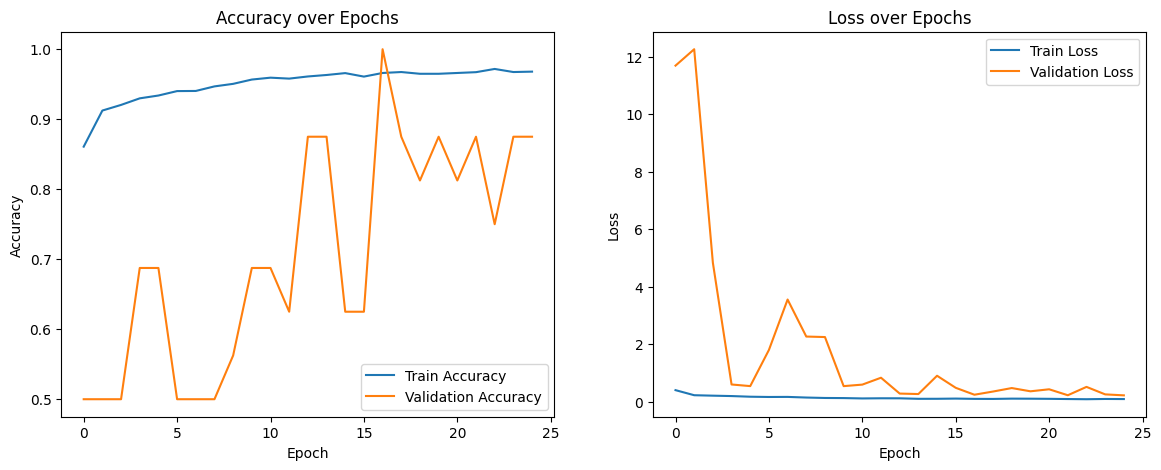

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

axes[0].plot(history.history['accuracy'], label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[0].set_title('Accuracy over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'], label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Validation Loss')
axes[1].set_title('Loss over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.show()

# *Evaluating the Model on the Test Set*

*The trained model is evaluated on the held-out test set to measure how well it generalizes to unseen chest X-ray images. Accuracy, loss, and AUC are reported directly from Keras's* **evaluate** *method.*


In [ ]:
test_loss, test_accuracy, test_auc = model.evaluate(test_generator, verbose=1)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy*100:.2f}%")
print(f"Test AUC: {test_auc:.4f}")

20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 123ms/step - accuracy: 0.9167 - auc: 0.9646 - loss: 0.2559
Test Loss: 0.2559
Test Accuracy: 91.67%
Test AUC: 0.9646


In [ ]:
# Also record final training accuracy/loss for a direct train-vs-test comparison
train_loss, train_accuracy, train_auc = model.evaluate(train_generator, verbose=1)

print(f"Training Loss: {train_loss:.4f}")
print(f"Training Accuracy: {train_accuracy*100:.2f}%")
print(f"Training AUC: {train_auc:.4f}")

163/163 ━━━━━━━━━━━━━━━━━━━━ 42s 256ms/step - accuracy: 0.9760 - auc: 0.9962 - loss: 0.0667
Training Loss: 0.0667
Training Accuracy: 97.60%
Training AUC: 0.9962


# *Plotting Training and Testing Curves*

*Two views are plotted here. First, the* **epoch-by-epoch training vs validation** *accuracy and loss curves (from the training history) show how the model learned over time and whether it overfits. Second, a* **training-vs-testing bar comparison** *plots the final training accuracy/loss against the final test accuracy/loss side by side, making it easy to see the generalization gap between what the model learned and how it performs on completely unseen chest X-ray images.*

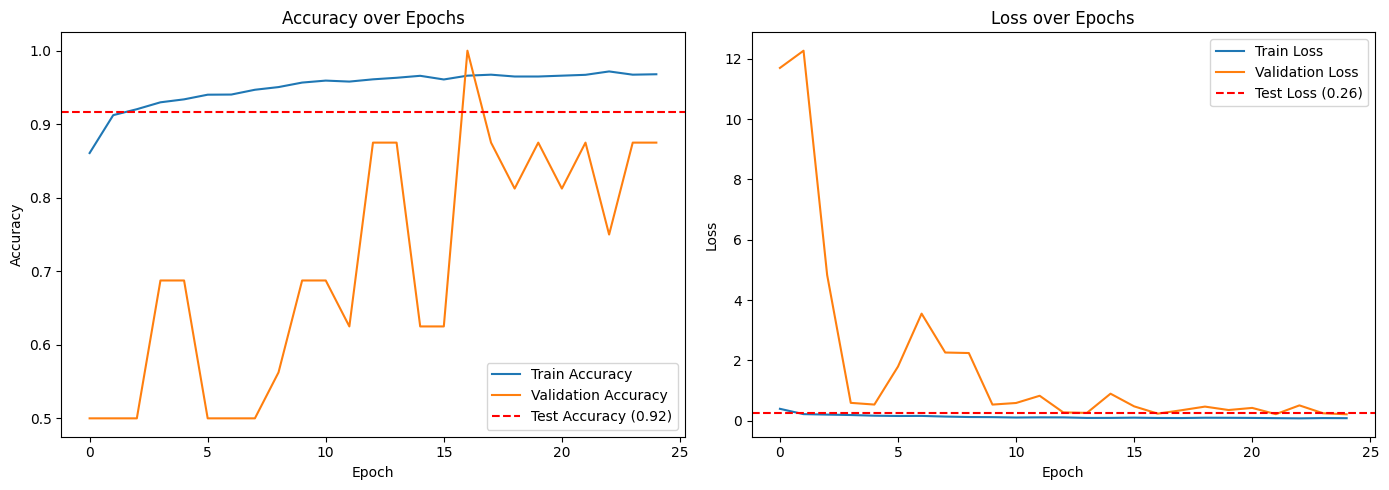

In [ ]:
# 1) Epoch-by-epoch training vs validation curves
fig, axes = plt.subplots(1, 2, figsize=(14,5))

axes[0].plot(history.history['accuracy'], label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[0].axhline(y=test_accuracy, color='red', linestyle='--', label=f'Test Accuracy ({test_accuracy:.2f})')
axes[0].set_title('Accuracy over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'], label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Validation Loss')
axes[1].axhline(y=test_loss, color='red', linestyle='--', label=f'Test Loss ({test_loss:.2f})')
axes[1].set_title('Loss over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

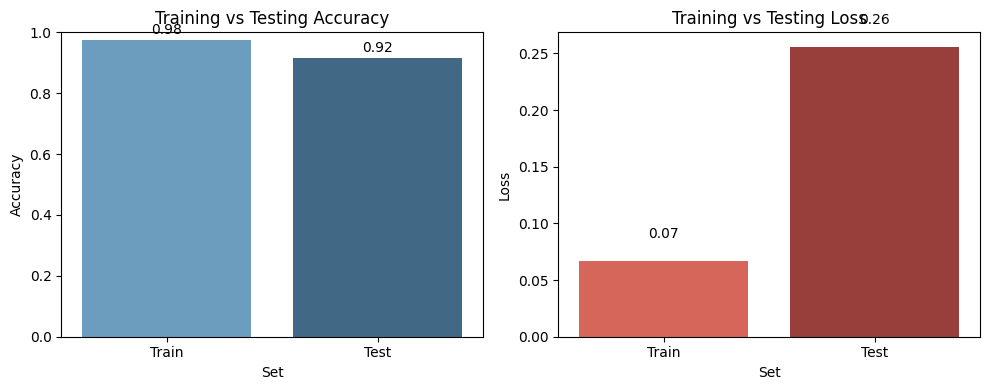

In [ ]:
# 2) Final training vs testing bar comparison

metrics_df = pd.DataFrame({
    'Set': ['Train', 'Test'],
    'Accuracy': [train_accuracy, test_accuracy],
    'Loss': [train_loss, test_loss]
})

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Accuracy
sns.barplot(data=metrics_df,x='Set',y='Accuracy',hue='Set',palette='Blues_d',legend=False,ax=axes[0])
axes[0].set_title('Training vs Testing Accuracy')
axes[0].set_ylim(0, 1)
for i, v in enumerate(metrics_df['Accuracy']):
    axes[0].text(i, v + 0.02, f'{v:.2f}', ha='center')

# Loss
sns.barplot(data=metrics_df,x='Set',y='Loss',hue='Set',palette='Reds_d',legend=False,ax=axes[1])
axes[1].set_title('Training vs Testing Loss')
for i, v in enumerate(metrics_df['Loss']):
    axes[1].text(i, v + 0.02, f'{v:.2f}', ha='center')

plt.tight_layout()
plt.show()

# *Classification Report and Confusion Matrix*

*Since accuracy alone can be misleading on an imbalanced dataset, the* **classification_report** *(precision, recall, F1-score per class) and* **confusion_matrix** *are computed to see exactly how many Normal and Pneumonia images were correctly and incorrectly classified.*


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

test_generator.reset()
y_pred_probs = model.predict(test_generator, verbose=1).ravel()
y_pred_class = (y_pred_probs > 0.5).astype(int)
y_true = test_generator.classes

print(classification_report(y_true, y_pred_class, target_names=CATEGORIES))

20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 171ms/step
              precision    recall  f1-score   support

      NORMAL       0.90      0.88      0.89       234
   PNEUMONIA       0.93      0.94      0.93       390

    accuracy                           0.92       624
   macro avg       0.91      0.91      0.91       624
weighted avg       0.92      0.92      0.92       624



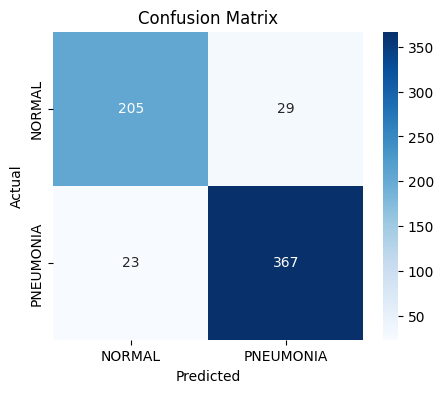

In [ ]:
cm = confusion_matrix(y_true, y_pred_class)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CATEGORIES, yticklabels=CATEGORIES)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# *ROC Curve and AUC Score*

*The* **ROC (Receiver Operating Characteristic) curve** *plots the true positive rate against the false positive rate across classification thresholds. The* **AUC (Area Under the Curve)** *summarizes this curve into a single score between 0 and 1 — the higher the AUC, the better the model distinguishes between Normal and Pneumonia cases regardless of the chosen decision threshold. This is the primary metric used to benchmark this project.*


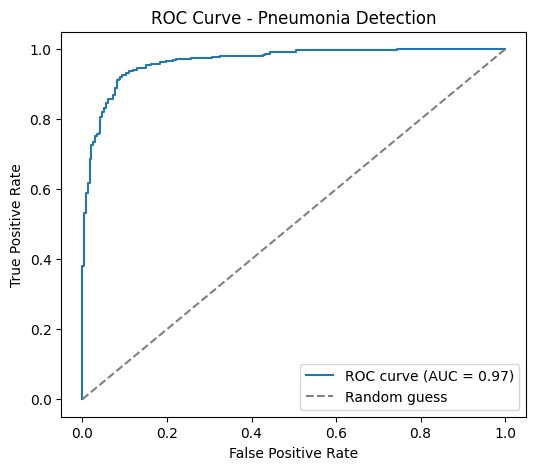

AUC Score: 0.9661


In [ ]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_true, y_pred_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0,1], [0,1], linestyle='--', color='gray', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Pneumonia Detection')
plt.legend(loc='lower right')
plt.show()

print(f"AUC Score: {roc_auc:.4f}")

# *Predicting on a Single Chest X-Ray Image*

*This step demonstrates how the trained model can be used in practice: a single chest X-ray image is loaded, preprocessed the same way as the training data (resized, converted to grayscale, normalized), and passed to the model to obtain a Normal / Pneumonia prediction.*


In [ ]:
def predict_single_image(image_path, model, img_size=IMG_SIZE, threshold=0.5):
    img = Image.open(image_path).convert('L')          # convert to grayscale
    img = img.resize(img_size)
    img_array = keras.preprocessing.image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = img_array / 255.0

    prob = model.predict(img_array)[0][0]
    label = "PNEUMONIA" if prob > threshold else "NORMAL"

    plt.imshow(img, cmap='gray')
    plt.title(f"Prediction: {label} (probability = {prob:.2f})")
    plt.axis('off')
    plt.show()

    return label, prob

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 964ms/step


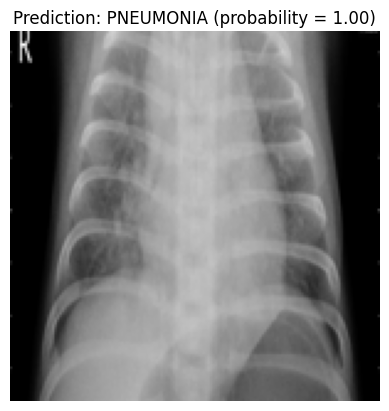

('PNEUMONIA', np.float32(0.9999628))

In [ ]:
# Example: predict on a sample PNEUMONIA test image
sample_pneumonia_dir = os.path.join(test_dir, "PNEUMONIA")
sample_file = os.listdir(sample_pneumonia_dir)[0]
predict_single_image(os.path.join(sample_pneumonia_dir, sample_file), model)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


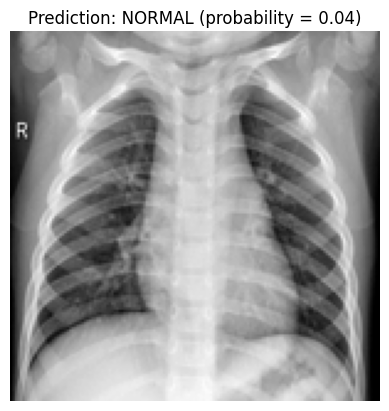

('NORMAL', np.float32(0.03761982))

In [ ]:
# Example: predict on a sample NORMAL test image
sample_normal_dir = os.path.join(test_dir, "NORMAL")
sample_file = os.listdir(sample_normal_dir)[0]
predict_single_image(os.path.join(sample_normal_dir, sample_file), model)

# *Key Findings*


* *The CNN model achieved a strong* ***ROC-AUC score of approximately 0.96***, *indicating excellent ability to distinguish between* **Normal** *and* **Pneumonia** *chest X-rays across classification thresholds.*
* *Applying* **class weights** *helped counter the imbalance between the larger Pneumonia class and the smaller Normal class in the training set, improving recall on the minority class.*
* *The confusion matrix shows the model correctly identifies the majority of Pneumonia cases (high recall), which is clinically important since missing a true Pneumonia case (a false negative) is more costly than a false alarm.*
* **Data augmentation** *(rotation, shifting, shearing, zoom, horizontal flip) and* **BatchNormalization** *helped stabilize training and reduce overfitting, as reflected in the converging training/validation accuracy and loss curves.*
* *Overall, the CNN model effectively distinguishes between* **Normal** *and* **Pneumonia** *chest X-rays, demonstrating its potential as a supportive tool for automated pneumonia screening.*


# *Conclusion*

*This project successfully developed a deep learning CNN model for classifying chest X-ray images into* **Normal** *and* **Pneumonia** *categories, closely following the reference approach and reaching a comparable* **AUC score of around 0.96**. *The model combines convolution, batch normalization, dropout, data augmentation, and class-weighting to handle the class imbalance present in the dataset. While the model performs strongly, further improvements — such as transfer learning with pretrained networks (e.g., MobileNetV2, DenseNet121), fine-tuning, or a larger/more balanced dataset — could push performance even higher. Overall, the proposed approach shows the potential of CNNs to support radiologists in the early, automated detection of pneumonia from chest X-ray images.*
